# 03 — Dataset Generation

Generate the training dataset for the surrogate model via LHS sampling + VLM evaluation.

## Steps
1. Latin Hypercube Sampling of the 30-variable design space
2. Batch VLM evaluation (center body + outer wing)
3. Data quality filtering
4. Exploratory data analysis
5. Save to Parquet

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from scipy.stats import qmc

from src.parameterization.design_variables import BWBParams, N_VARS, get_bounds_arrays, params_from_vector
from src.aero.evaluator import AeroEvaluator
from src.config import load_all
from src.optimization.database import EvaluationDatabase

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

from src.visualization.style import apply_style, COLORS
apply_style()

In [2]:
%load_ext autoreload
%autoreload 2

## 1. LHS Sampling

In [3]:
cfg = load_all()
mission = cfg['mission']
feasibility = cfg['feasibility']
evaluator = AeroEvaluator(
    mission=mission, feasibility=feasibility,
    controls=cfg['controls'], cg_config=cfg['cg'],
    avl_command=cfg['avl_command'],
    aero_model=cfg['aero_model'], structure_config=cfg['structure'],
)

lb, ub = get_bounds_arrays()

# --- Load existing database ---
db_path = '../data/eval_database.json'
try:
    db = EvaluationDatabase.load(db_path)
    n_existing = len(db)
    print(f'Loaded existing database: {n_existing} samples')
except FileNotFoundError:
    db = EvaluationDatabase()
    n_existing = 0
    print('No existing database found, starting fresh')

# --- Generate NEW LHS samples (different seed) ---
n_new = 5000  # number of new samples to add
seed = 123 + n_existing  # ensure different seed from previous runs

sampler = qmc.LatinHypercube(d=N_VARS, seed=seed)
if n_new > 0:
    samples = sampler.random(n=n_new)
    X = qmc.scale(samples, lb, ub)
else:
    X = np.empty((0, N_VARS))  # No new samples
    
print(f'Generated {n_new} NEW LHS samples (seed={seed})')
print(f'After evaluation, total will be: {n_existing} + {n_new} = {n_existing + n_new}')

No existing database found, starting fresh
Generated 5000 NEW LHS samples (seed=123)
After evaluation, total will be: 0 + 5000 = 5000


## 2. Batch VLM Evaluation

In [4]:
t0 = time.time()

for i, x in enumerate(X):
    params = params_from_vector(x)
    result = evaluator.evaluate(params)
    db.add(x, result)
    
    if (i + 1) % 50 == 0 or i == 0 or i == len(X) - 1:
        elapsed = time.time() - t0
        rate = (i + 1) / elapsed
        n_total = len(db)
        n_feas = sum(1 for r in db.results if r.get('is_feasible', False))
        print(f'  {i+1:5d}/{n_new} ({rate:.1f}/s) | total={n_total} | feasible={n_feas}', flush=True)

    # Checkpoint every 1000 samples
    if (i + 1) % 1000 == 0:
        db.save(db_path)

elapsed = time.time() - t0
print(f'\nDone in {elapsed:.0f}s — {len(db)} total samples')

      1/5000 (3.0/s) | total=1 | feasible=0
     50/5000 (3.3/s) | total=50 | feasible=3
    100/5000 (3.3/s) | total=100 | feasible=3
    150/5000 (3.4/s) | total=150 | feasible=5
    200/5000 (3.4/s) | total=200 | feasible=7
    250/5000 (3.4/s) | total=250 | feasible=9
    300/5000 (3.4/s) | total=300 | feasible=10
    350/5000 (3.4/s) | total=350 | feasible=11
    400/5000 (3.4/s) | total=400 | feasible=13
    450/5000 (3.4/s) | total=450 | feasible=14
    500/5000 (3.4/s) | total=500 | feasible=16
    550/5000 (3.4/s) | total=550 | feasible=16
    600/5000 (3.4/s) | total=600 | feasible=18
    650/5000 (3.4/s) | total=650 | feasible=22
    700/5000 (3.4/s) | total=700 | feasible=23
    750/5000 (3.4/s) | total=750 | feasible=24
    800/5000 (3.4/s) | total=800 | feasible=25
    850/5000 (3.4/s) | total=850 | feasible=27
    900/5000 (3.4/s) | total=900 | feasible=27
    950/5000 (3.4/s) | total=950 | feasible=30
   1000/5000 (3.4/s) | total=1000 | feasible=38
   1050/5000 (3.4/s) 

## 3. Dataset Statistics

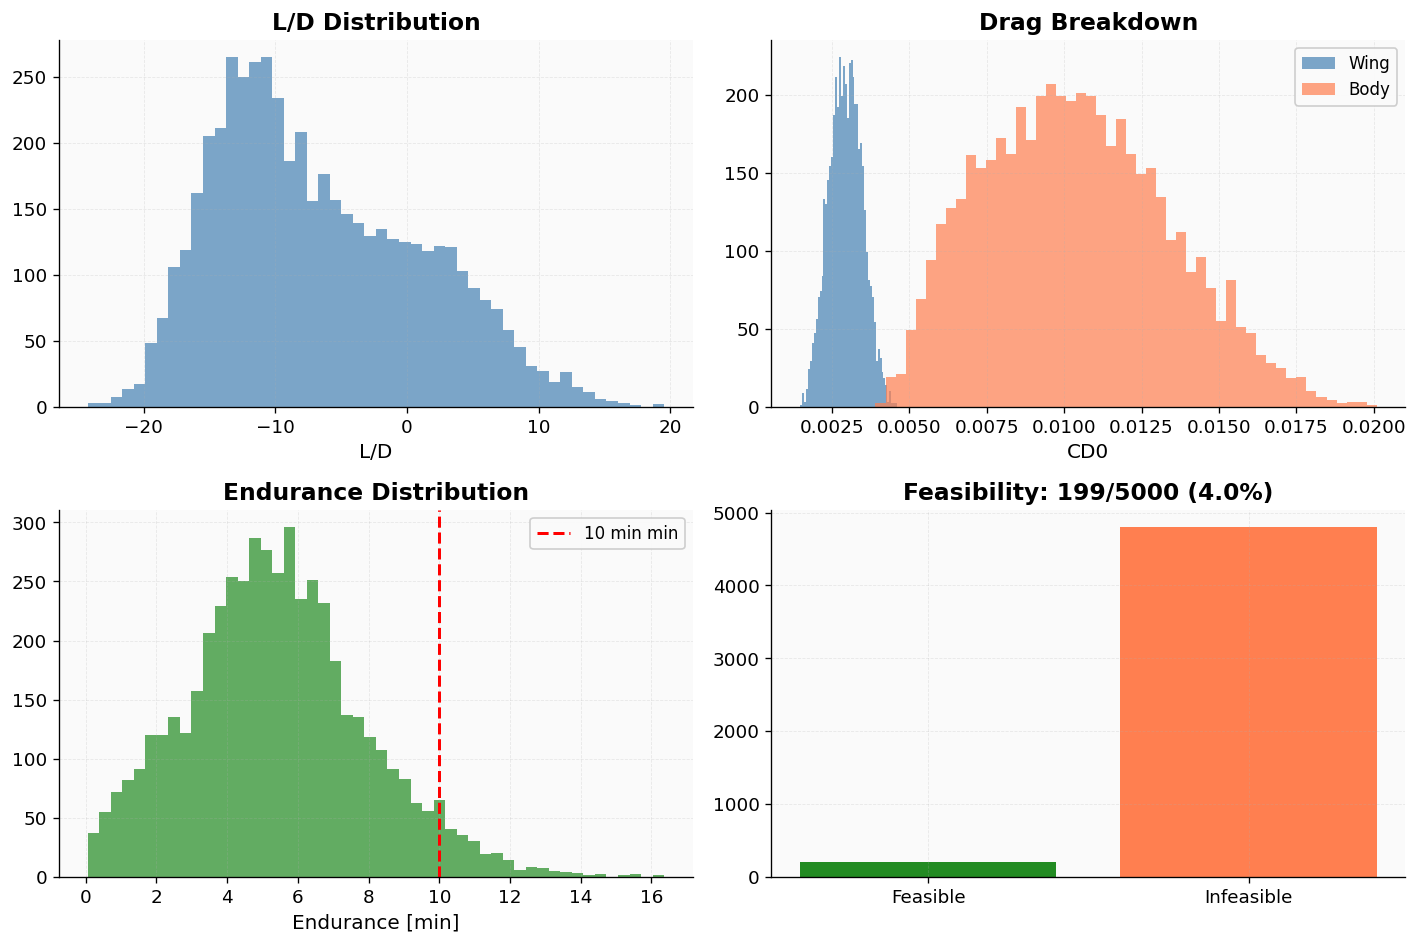

In [5]:
# Extract key metrics
X_arr, results = db.to_arrays()
n_total = len(results)
ld_values = [r['L_over_D'] for r in results]
cd0_wing = [r['CD0_wing'] for r in results]
cd0_body = [r['CD0_body'] for r in results]
endurance = [r.get('endurance_min', 0) for r in results]
feasible = [r['is_feasible'] for r in results]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(ld_values, bins=50, color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('L/D')
axes[0, 0].set_title('L/D Distribution')

axes[0, 1].hist(cd0_wing, bins=50, color='steelblue', alpha=0.7, label='Wing')
axes[0, 1].hist(cd0_body, bins=50, color='coral', alpha=0.7, label='Body')
axes[0, 1].set_xlabel('CD0')
axes[0, 1].set_title('Drag Breakdown')
axes[0, 1].legend()

axes[1, 0].hist(endurance, bins=50, color='forestgreen', alpha=0.7)
axes[1, 0].axvline(10, color='red', ls='--', label='10 min min')
axes[1, 0].set_xlabel('Endurance [min]')
axes[1, 0].set_title('Endurance Distribution')
axes[1, 0].legend()

axes[1, 1].bar(['Feasible', 'Infeasible'], [sum(feasible), sum(not f for f in feasible)],
               color=['forestgreen', 'coral'])
axes[1, 1].set_title(f'Feasibility: {sum(feasible)}/{n_total} ({sum(feasible)/n_total:.1%})')

plt.tight_layout()
plt.show()

## 4. Save Dataset

In [6]:
# Save database for surrogate training
db.save(db_path)

# Also save as Parquet for fast loading
X_arr, results = db.to_arrays()
records = []
for x, r in zip(X_arr, results):
    row = {f'x_{i}': float(x[i]) for i in range(N_VARS)}
    for k, v in r.items():
        if isinstance(v, (int, float, bool, np.floating, np.integer, np.bool_)):
            row[k] = float(v) if not isinstance(v, bool) else v
    records.append(row)

df = pd.DataFrame(records)
df.to_parquet('../data/dataset_v2.parquet', index=False)
print(f'Saved {len(df)} total samples to data/dataset_v2.parquet')
print(f'Columns: {len(df.columns)}')

Saved 5000 total samples to data/dataset_v2.parquet
Columns: 77
